In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader

### Get File path and load the csv data

In [26]:
from util.data_path import cassava_path

In [27]:
wide = pd.read_csv(cassava_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [28]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

### Create a sequence dataset class for LSTM prediction

In [29]:
from util.lstm_cust_class import SeqDataset

SEQ_LEN = 12
PRED_LEN = 12

In [30]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

### Create the LSTM regression model class

In [31]:
from util.lstm_cust_class import LSTMRegressor

### Training the LSTM model

In [32]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00393
epoch 100/300  loss=0.00170
epoch 150/300  loss=0.00119
epoch 200/300  loss=0.00118
epoch 250/300  loss=0.00117
epoch 300/300  loss=0.00119


### Predict the data for the next year

In [33]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.49
2024-02-01    3.29
2024-03-01    3.17
2024-04-01    3.09
2024-05-01    3.02
2024-06-01    2.95
2024-07-01    2.87
2024-08-01    2.80
2024-09-01    2.73
2024-10-01    2.67
2024-11-01    2.61
2024-12-01    2.56
Freq: MS, Name: forecast_price, dtype: float64


In [34]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.49
2024-02-01    3.65            3.29
2024-03-01    3.57            3.17
2024-04-01    3.24            3.09
2024-05-01    3.19            3.02
2024-06-01    3.09            2.95
2024-07-01    3.06            2.87
2024-08-01    2.95            2.80
2024-09-01    2.86            2.73
2024-10-01    2.65            2.67
2024-11-01    2.60            2.61
2024-12-01    2.32            2.56


### Compare The Error of a predicted data and the actual data in a table format

In [35]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = error.abs()
pct_error = (error / cmp["actual"]) * 100


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "pct_error": pct_error,
    }
)
print(error_df.round(4))

average_percent_error = 0
for error_val in pct_error:
    average_percent_error += abs(error_val)

average_percent_error /= len(pct_error)
print(f"\n--- Average Percent Error: {average_percent_error:.2f}% ---")


--- Monthly Errors ---
            actual  forecast   error  abs_error  pct_error
2024-01-01    3.65    3.4930  0.1570     0.1570     4.3006
2024-02-01    3.65    3.2947  0.3553     0.3553     9.7334
2024-03-01    3.57    3.1698  0.4002     0.4002    11.2111
2024-04-01    3.24    3.0905  0.1495     0.1495     4.6132
2024-05-01    3.19    3.0197  0.1703     0.1703     5.3397
2024-06-01    3.09    2.9454  0.1446     0.1446     4.6810
2024-07-01    3.06    2.8701  0.1899     0.1899     6.2061
2024-08-01    2.95    2.7981  0.1519     0.1519     5.1508
2024-09-01    2.86    2.7313  0.1287     0.1287     4.5002
2024-10-01    2.65    2.6702 -0.0202     0.0202    -0.7634
2024-11-01    2.60    2.6145 -0.0145     0.0145    -0.5593
2024-12-01    2.32    2.5640 -0.2440     0.2440   -10.5151

--- Average Percent Error: 5.63% ---


### Plot The predicted data compare to an actual data

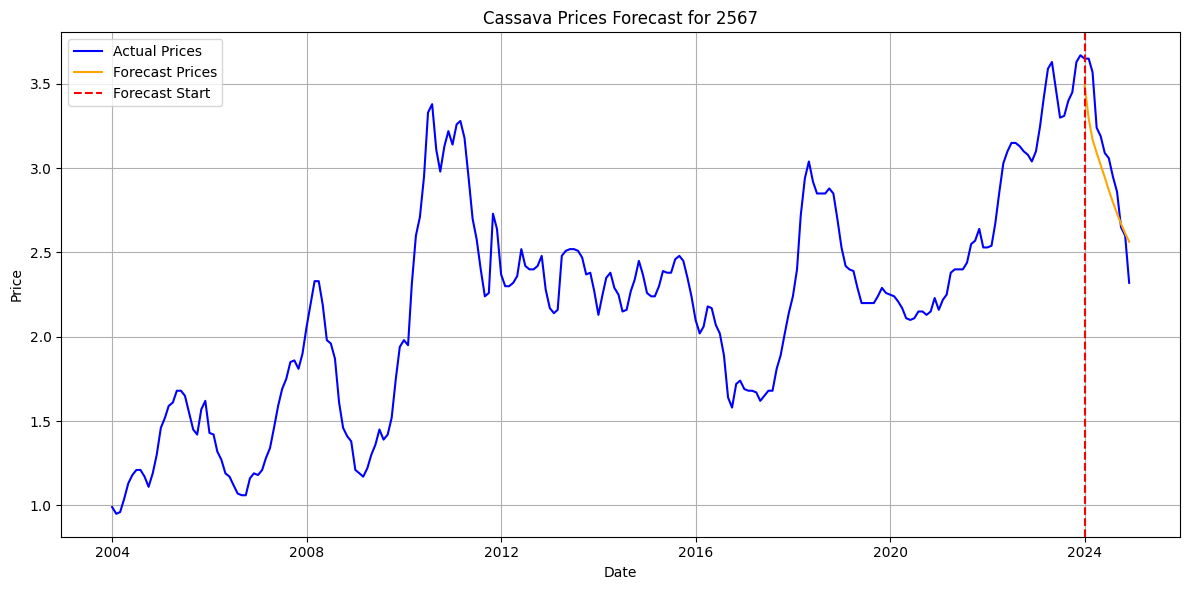

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()